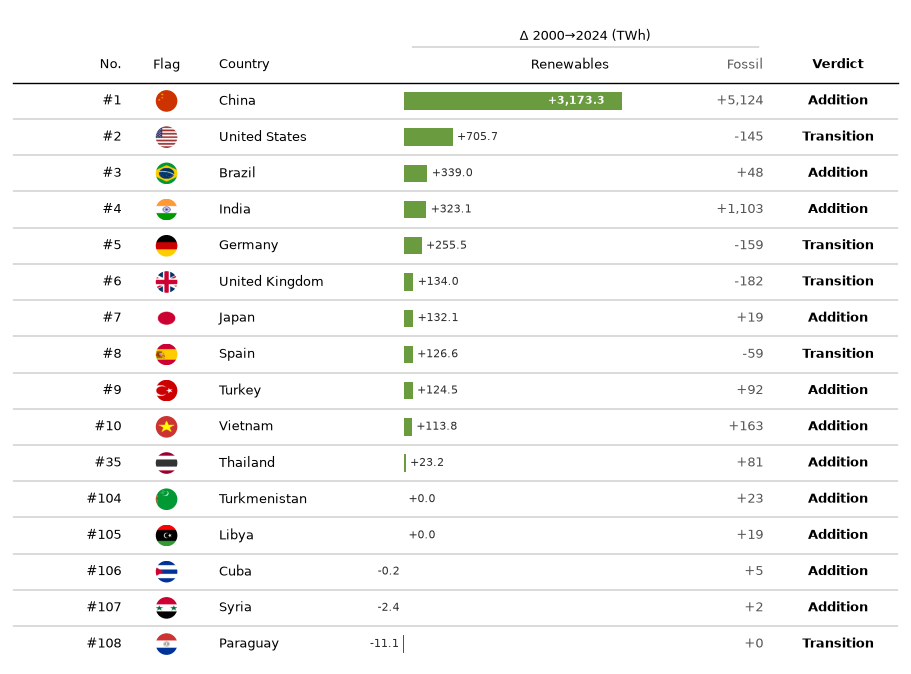

In [2]:
# ก่อนรัน ต้องติดตั้งก่อน:
# pip install plottable flagpy pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import flagpy
import os
from plottable import Table, ColumnDefinition
from plottable.plots import circled_image

# ---------- 1. โหลดและเตรียมข้อมูล ----------
df = pd.read_csv('renewable_energy_countries_selected_v7.csv')
df = df[df['year'] <= 2024]
df['fossil'] = df['coal_electricity'] + df['gas_electricity'] + df['oil_electricity']
df['renewables'] = df['hydro_electricity'] + df['solar_electricity'] + df['wind_electricity'] + df['other_renewable_electricity']

p0 = df[df.year==2000][['country','fossil','renewables','electricity_generation']].rename(columns={'fossil':'fossil_2000','renewables':'ren_2000'})
p1 = df[df.year==2024][['country','fossil','renewables','electricity_generation']].rename(columns={'fossil':'fossil_2024','renewables':'ren_2024','electricity_generation':'gen_2024'})
m = p0.merge(p1, on='country').dropna(subset=['electricity_generation','gen_2024'])
m = m[m['gen_2024'] >= 10]
m['delta_fossil'] = m['fossil_2024'] - m['fossil_2000']
m['delta_ren'] = m['ren_2024'] - m['ren_2000']

# ---------- 2. เลือกประเทศด้วยเกณฑ์ RE ล้วนๆ: Top 10 + Thailand + Bottom 5 ----------
full_rank = m.sort_values('delta_ren', ascending=False).reset_index(drop=True)
full_rank['global_rank'] = range(1, len(full_rank) + 1)

top10 = full_rank.head(10)
bottom5 = full_rank.tail(5)
thailand = full_rank[full_rank.country == 'Thailand']

plot_data = pd.concat([top10, thailand, bottom5]).drop_duplicates(subset='country')
plot_data = plot_data.sort_values('delta_ren', ascending=False).reset_index(drop=True)
plot_data['verdict'] = plot_data['delta_fossil'].apply(lambda x: 'Addition' if x > 0 else 'Transition')

# ---------- 3. โหลดธง ----------
name_map = {
    'United States': 'The United States',
    'United Kingdom': 'The United Kingdom',
    'Netherlands': 'The Netherlands',
    'Czechia': 'The Czech Republic',
}
os.makedirs('flags_final3', exist_ok=True)
flag_paths = {}
for c in plot_data['country']:
    fp_name = name_map.get(c, c)
    img = flagpy.get_flag_img(fp_name)
    path = f'flags_final3/{c}.png'
    img.save(path)
    flag_paths[c] = path
plot_data['flag'] = plot_data['country'].map(flag_paths)

# ---------- 4. เตรียม DataFrame สำหรับตาราง ----------
# No. = อันดับจริงระดับโลก (ไม่ใช่แค่ลำดับใน list นี้)
plot_data['no_label'] = plot_data['global_rank'].apply(lambda x: f'#{x}')
table_df = plot_data[['no_label','flag','country','delta_ren','delta_fossil','verdict']].copy()
table_df.columns = ['No.','Flag','Country','Renewables','Fossil','Verdict']
table_df = table_df.set_index('No.')

COLOR_GREEN_REN = '#6a9c3f'
COLOR_ORANGE = '#F97F01'
COLOR_GREEN = '#426214'

def verdict_colors(vals):
    return [COLOR_ORANGE if v == 'Addition' else COLOR_GREEN for v in vals]

# ---------- 5. custom bar-in-cell เฉพาะ Renewables (Fossil เป็นตัวหนังสือธรรมดา) ----------
ren_min, ren_max = table_df['Renewables'].min(), table_df['Renewables'].max()

def ren_bar(ax, val, **kwargs):
    ax.barh(0.5, val, fc=COLOR_GREEN_REN if val >= 0 else '#a03030', ec='None', zorder=0.05)
    xlim = (ren_min, ren_max)
    pad = 0.05 * abs(xlim[1] - xlim[0])
    ax.set_xlim(xlim[0] - pad, xlim[1] + pad)
    ax.set_ylim(0, 1)
    bar_frac = abs(val) / abs(xlim[1] - xlim[0])
    if bar_frac > 0.55:
        ax.text(val * 0.92, 0.5, f'{val:+,.1f}', ha='right' if val >= 0 else 'left',
                 va='center', fontsize=8, color='white', fontweight='bold', zorder=0.3)
    else:
        ax.text(val + (pad * 0.4 if val >= 0 else -pad * 0.4), 0.5, f'{val:+,.1f}',
                 ha='left' if val >= 0 else 'right', va='center', fontsize=8, color='#2B2B2B', zorder=0.3)
    ax.axis('off')

# ---------- 6. Column definitions ----------
col_defs = [
    ColumnDefinition(name='Flag', width=0.55, plot_fn=circled_image, textprops={'ha':'center'}),
    ColumnDefinition(name='Country', width=1.6, textprops={'ha':'left'}),
    ColumnDefinition(name='Renewables', width=2.0, formatter='{:+,.1f}',
                      group='\u0394 2000\u21922024 (TWh)', plot_fn=ren_bar),
    # Fossil: ตัวหนังสือธรรมดา ไม่มีแท่ง ไม่มีสี (สีเทา) เพื่อให้ Renewables เด่นเป็นพระเอก
    ColumnDefinition(name='Fossil', width=1.2, formatter='{:+,.0f}',
                      group='\u0394 2000\u21922024 (TWh)', textprops={'ha':'right','color':'#555555'}),
    ColumnDefinition(name='Verdict', width=1.0, textprops={'ha':'center','weight':'bold'},
                      text_cmap=verdict_colors),
]

# ---------- 7. วาดตาราง ----------
fig, ax = plt.subplots(figsize=(11.5, 8.5))
fig.patch.set_facecolor('white')

tab = Table(
    table_df, column_definitions=col_defs, ax=ax,
    textprops={'fontsize': 9.5},
    row_dividers=True, col_label_divider=True,
)

plt.savefig('part3_re_only_highlight.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()

In [13]:
# pip install plotly kaleido  (เพิ่มเข้าไปใน comment บรรทัดบนสุดของไฟล์ด้วย)
import plotly.graph_objects as go
import numpy as np

# ---------- 6. เตรียมข้อมูลสำหรับ Choropleth Map (ไม่ตัดประเทศ gen < 10 TWh) ----------
iso_map = df[['country', 'iso_code']].drop_duplicates()

m_map = p0.merge(p1, on='country').dropna(subset=['electricity_generation', 'gen_2024'])
# หมายเหตุ: ตรงนี้ "ไม่มี" บรรทัด m_map = m_map[m_map['gen_2024'] >= 10] ตามที่ต้องการ

m_map['delta_fossil'] = m_map['fossil_2024'] - m_map['fossil_2000']
m_map['delta_ren'] = m_map['ren_2024'] - m_map['ren_2000']

# กรองเฉพาะ Real Transition: fossil ลด และ renewable เพิ่มจริง
real_transition_map = m_map[(m_map['delta_fossil'] < 0) & (m_map['delta_ren'] > 0)].copy()

# เติม iso_code เพื่อใช้ plot แผนที่
real_transition_map = real_transition_map.merge(iso_map, on='country', how='left')
real_transition_map = real_transition_map.dropna(subset=['iso_code'])  # ตัดประเทศที่ไม่มี iso_code (ใช้ choropleth ไม่ได้)

print(f'จำนวนประเทศ Real Transition ทั้งหมด: {len(real_transition_map)}')

# ---------- 7. วาด Choropleth Map ----------
green_scale = [
    [0.0, "#f0fcf3"],
    [0.15, '#e0f3db'],
    [0.30, '#ccebc5'],
    [0.45, '#a8ddb5'],
    [0.60, "#61A589"],
    [0.75, "#47866C"],
    [0.88, "#3A6D59"],
    [1.0, '#254538'],
]

# ข้อมูลเบ้ขวา (บางประเทศ delta_ren สูงมาก) ใช้ log scale ให้เห็นความต่างชัดขึ้น
real_transition_map['log_delta_ren'] = np.log10(real_transition_map['delta_ren'] + 1)

tick_vals_actual = [0, 1, 5, 20, 100, 500,
                     int(real_transition_map['delta_ren'].max())]
tick_vals_log = [np.log10(v + 1) for v in tick_vals_actual]
tick_text = [f'{v:,}' for v in tick_vals_actual]

fig_map.update_layout(
    title=dict(
        text='ประเทศที่มีการเปลี่ยนผ่านพลังงานจริง (Real Transition) 2000 → 2024'
             '<br><sub>Fossil ลดลง และ Renewables เพิ่มขึ้นจริง | รวมทุกประเทศ ไม่กรองขนาดการผลิตไฟฟ้า</sub>',
        x=0.5,
        font=dict(size=15),
    ),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='#d9d9d9',      # <-- เส้นชายฝั่งเทาอ่อนด้วยให้เข้าธีมเดียวกัน
        showcountries=True,             # <-- เปิดเส้นขอบประเทศทั้งหมด รวมประเทศที่ไม่มีข้อมูล
        countrycolor='#d9d9d9',         # <-- สีเส้นขอบประเทศ (สำหรับประเทศที่ไม่มี z value)
        landcolor='#f5f5f5',            # <-- สีพื้นประเทศที่ไม่มีข้อมูล (เทาอ่อนมาก แทนที่จะเป็นขาวล้วน)
        projection_type='natural earth',
        bgcolor='white',
    ),
    margin=dict(l=10, r=10, t=90, b=10),
    paper_bgcolor='white',
    width=1200,
    height=650,
)

fig_map.update_layout(
    title=dict(
        text='ประเทศที่มีการเปลี่ยนผ่านพลังงานจริง (Real Transition) 2000 → 2024'
             '<br><sub>Fossil ลดลง และ Renewables เพิ่มขึ้นจริง | รวมทุกประเทศ ไม่กรองขนาดการผลิตไฟฟ้า</sub>',
        x=0.5,
        font=dict(
            family="TH Sarabun", # <--- เพิ่มชื่อฟอนต์ตรงนี้
            size=20
        ),
    ),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='#d9d9d9',      
        showcountries=True,            
        countrycolor='#d9d9d9',        
        landcolor='#f5f5f5',           
        projection_type='natural earth',
        bgcolor='white',
    ),
    margin=dict(l=10, r=10, t=90, b=10),
    paper_bgcolor='white',
    width=1200,
    height=650,
)

fig_map.write_html('act3_real_transition_map.html')
fig_map.write_image('act3_real_transition_map.png', scale=2)  # ต้องมี Chrome ติดตั้งไว้ (kaleido v1+)
fig_map.show()

จำนวนประเทศ Real Transition ทั้งหมด: 53


In [ ]:
"""CONTINENT_COLORS = {
    'Asia': "#F0B521",
    'Africa': "#F7671F",
    'North America': "#3DD9F1",
    'South America': "#01A093",
    'Europe': "#B42EED",
    'Oceania': "#1F3DEC"
}"""

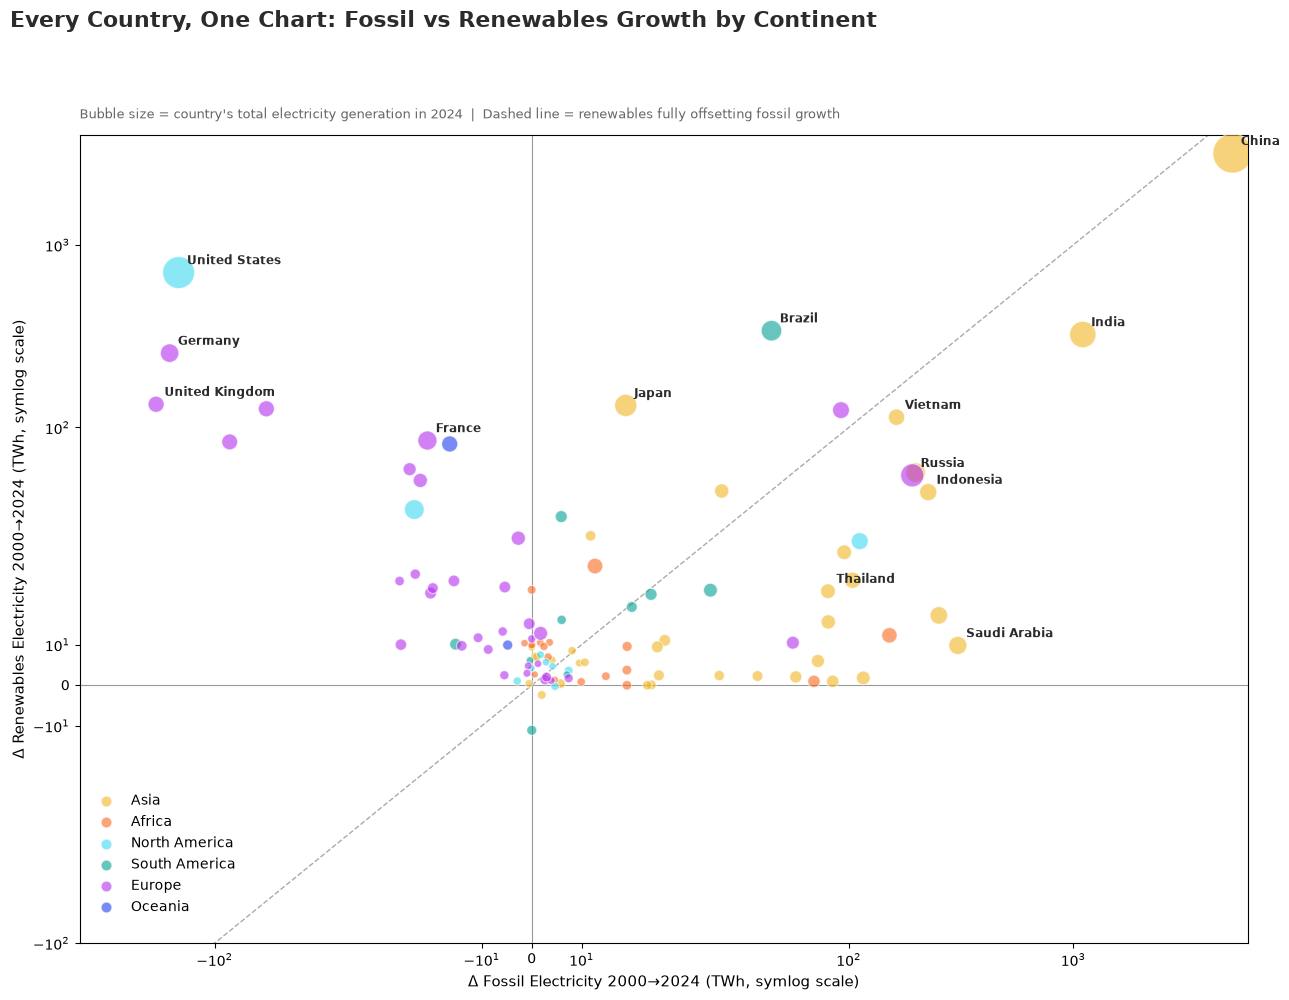

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('renewable_energy_countries_selected_v7.csv')
df = df[df['year'] <= 2024]
df['fossil'] = df['coal_electricity'] + df['gas_electricity'] + df['oil_electricity']
df['renewables'] = df['hydro_electricity'] + df['solar_electricity'] + df['wind_electricity'] + df['other_renewable_electricity']

# ดึง continent มาด้วย (ต้องมีคอลัมน์นี้ใน p1 เพื่อไม่ให้หายตอน merge)
p0 = df[df.year==2000][['country','fossil','renewables']].rename(columns={'fossil':'fossil_2000','renewables':'ren_2000'})
p1 = df[df.year==2024][['country','fossil','renewables','electricity_generation','continent']].rename(columns={'fossil':'fossil_2024','renewables':'ren_2024'})
m = p0.merge(p1, on='country').dropna()
m = m[m['electricity_generation'] >= 10]
m['delta_fossil'] = m['fossil_2024'] - m['fossil_2000']
m['delta_ren'] = m['ren_2024'] - m['ren_2000']

COLOR_DARK = '#2B2B2B'

# ---------- สีตามทวีป ----------
CONTINENT_COLORS = {
    'Asia': "#F0B521",
    'Africa': "#F7671F",
    'North America': "#3DD9F1",
    'South America': "#01A093",
    'Europe': "#B42EED",
    'Oceania': "#1F3DEC"
}

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ใช้ลำดับตาม dict เพื่อคุมลำดับ legend
for continent, color in CONTINENT_COLORS.items():
    sub = m[m['continent'] == continent]
    if sub.empty:
        continue
    sizes = np.sqrt(sub['electricity_generation']) * 8
    ax.scatter(sub['delta_fossil'], sub['delta_ren'], s=sizes, color=color, alpha=0.6,
               edgecolor='white', linewidth=0.8, label=continent, zorder=3)

lims = (-400, 6000)
ax.plot(lims, lims, linestyle='--', color=COLOR_DARK, linewidth=1, alpha=0.4, zorder=1)

ax.axhline(0, color='#999999', linewidth=0.8, zorder=1)
ax.axvline(0, color='#999999', linewidth=0.8, zorder=1)

label_countries = ['China','United States','India','Germany','United Kingdom','Japan','Brazil',
                    'Russia','Saudi Arabia','Vietnam','Thailand','France','Indonesia']
for _, row in m[m.country.isin(label_countries)].iterrows():
    ax.annotate(row['country'], (row['delta_fossil'], row['delta_ren']),
                xytext=(6, 6), textcoords='offset points', fontsize=8.5, color=COLOR_DARK, fontweight='bold')

ax.set_xscale('symlog', linthresh=50)
ax.set_yscale('symlog', linthresh=50)
ax.set_xlim(-400, 6000)
ax.set_ylim(-100, 4000)

ax.set_xlabel('Δ Fossil Electricity 2000→2024 (TWh, symlog scale)', fontsize=11)
ax.set_ylabel('Δ Renewables Electricity 2000→2024 (TWh, symlog scale)', fontsize=11)

fig.suptitle('Every Country, One Chart: Fossil vs Renewables Growth by Continent', fontsize=16, fontweight='bold',
             color=COLOR_DARK, x=0.01, ha='left', y=0.995)
ax.set_title("Bubble size = country's total electricity generation in 2024  |  Dashed line = renewables fully offsetting fossil growth",
             fontsize=9.5, color='#666666', loc='left', pad=12)
# 1. สร้าง legend และเก็บไว้ในตัวแปร leg (ลบ markerscale ออกได้เลย)
leg = ax.legend(loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(0.0, 0.02))

# 2. วนลูปเพื่อบังคับขนาดของวงกลมใน legend ให้เท่ากันทั้งหมด
for handle in leg.legend_handles:
    handle.set_sizes([60])  # ปรับตัวเลข 60 ตรงนี้เพื่อเพิ่ม/ลดขนาดของวงกลมในกล่องได้ตามต้องการ

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('bubble_all_countries_by_continent.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()